# 03 · Evaluación en hold-out y análisis de negocio

Fase 5 de CRISP-DM. **Única** evaluación sobre `banca_test.csv` (4.521 filas, independiente del train tras la limpieza de la Fase 0), con el modelo ya elegido y el umbral ya fijado. Lógica en `evaluate.py`, `explain.py` y `business.py`.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display, Markdown
from bank_captacion import config as cfg
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

def show(fig):
    display(Image(filename=str(cfg.FIGURES_DIR / fig)))

def table(name, **kw):
    df = pd.read_csv(cfg.TABLES_DIR / name, **kw)
    display(df)
    return df


In [2]:
print((cfg.TABLES_DIR / 'holdout_usage.json').read_text())

{
  "holdout_file": "banca_test.csv",
  "rows": 4521,
  "evaluated_utc": "2026-09-29T02:28:43.982319+00:00",
  "model_file_sha256": "36f3f13a431524d3ea41927d622f7c3fa399eac0cccebf76b67708b424bb81a7",
  "note": "EvaluaciÃ³n Ãºnica del modelo ya seleccionado; modelo, hiperparÃ¡metros y umbral se fijaron con train (CV). NingÃºn resultado de este archivo se usÃ³ para decidir."
}


## 1. Métricas en test: modelo final vs baselines

,model,label,roc_auc,pr_auc,lift@10,gain@10,lift@20,gain@20,lift@30,gain@30,brier,threshold_at_thr,precision_at_thr,recall_at_thr,f1_at_thr,contacted_pct_at_thr,profit_at_thr
0,final,"LightGBM (final, pre-contacto)",0.7836,0.4354,4.2143,0.4223,2.9820,0.5969,2.2573,0.6775,0.0822,0.050,0.1633,0.8656,0.2747,61.0927,6258.0
1,logreg,Regresión logística (baseline),0.7379,0.3494,3.8120,0.3820,2.4546,0.4914,1.9823,0.5950,0.1834,0.275,0.1453,0.9002,0.2502,71.4001,6152.0
2,dummy,Dummy (prior),0.5000,0.1152,1.0919,0.1094,0.9876,0.1977,1.0295,0.3090,0.1020,0.050,0.1152,1.0000,0.2067,100.0000,5899.0
3,with_duration,LightGBM + duration (leakage),0.9326,0.6072,5.4785,0.5489,4.1614,0.8330,3.1526,0.9463,0.0622,0.050,0.3264,0.9693,0.4884,34.2181,8553.0


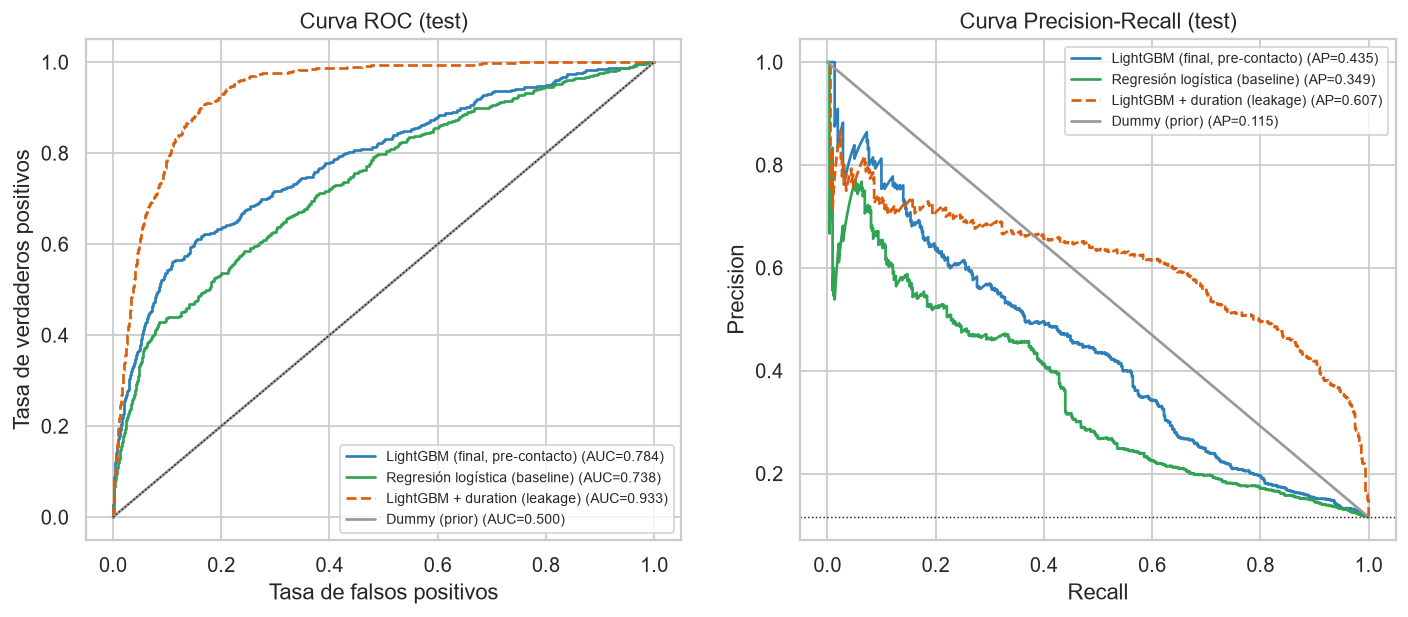

In [3]:
table('test_metrics.csv')
show('test_roc_pr_curves.png')

- **Modelo final (LightGBM pre-contacto)**: ROC-AUC 0,784, PR-AUC 0,435, lift@10 % = 4,2. Supera claramente a la regresión logística (PR-AUC 0,349) y al Dummy (0,115 = prevalencia).
- Frente a la CV (PR-AUC 0,466 ± 0,020) el test da algo menos (−0,03, dentro de 2 desvíos). Es la caída esperable: la CV del modelo tuneado es levemente optimista porque los hiperparámetros se eligieron mirando esos folds, y el test tiene solo 521 conversiones (más varianza).
- La variante con `duration` llega a ROC-AUC 0,933, pero no es utilizable (ver sección 6).

## 2. Matriz de confusión al umbral operativo

,Unnamed: 0,predicho: no llamar,predicho: llamar
0,real: no convierte,1689,2311
1,real: convierte,70,451


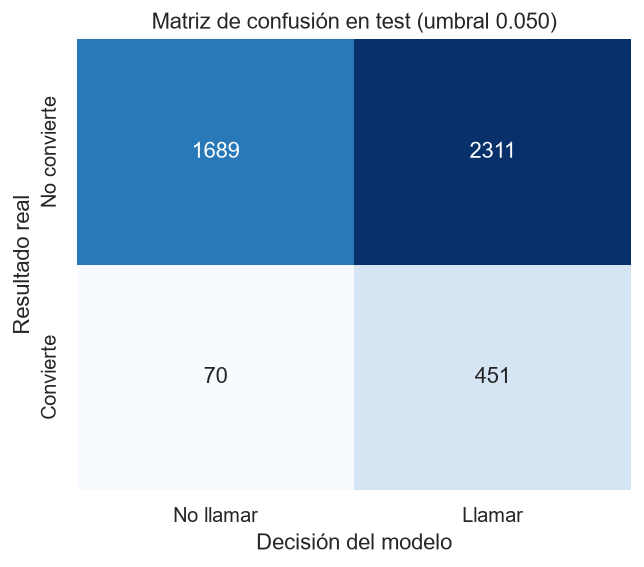

In [4]:
table('test_confusion_matrix.csv')
show('test_confusion_matrix.png')

Con el umbral de 0,05 el modelo recomienda llamar al 61 % de los clientes y captura 451 de las 521 conversiones (recall 86,6 %), con 2.311 falsos positivos. Esos falsos positivos son **aceptables por diseño**: con V/C = 20 una llamada sin conversión cuesta 1 y una conversión perdida cuesta 20.

## 3. Deciles, gain y lift

,decile,n,conversions,conversion_rate,lift,cum_n,cum_pct_contacted,cum_conversions,cum_gain_pct,cum_lift,score_min,score_max
0,1,453,220,0.4857,4.2143,453,10.0199,220,42.2265,4.2143,0.3041,0.8774
1,2,452,91,0.2013,1.7470,905,20.0177,311,59.6929,2.9820,0.1268,0.3024
2,3,452,42,0.0929,0.8063,1357,30.0155,353,67.7543,2.2573,0.0901,0.1265
3,4,452,35,0.0774,0.6719,1809,40.0133,388,74.4722,1.8612,0.0721,0.0901
4,5,452,33,0.0730,0.6335,2261,50.0111,421,80.8061,1.6158,0.0605,0.0720
5,6,452,26,0.0575,0.4992,2713,60.0088,447,85.7965,1.4297,0.0510,0.0604
6,7,452,31,0.0686,0.5951,3165,70.0066,478,91.7466,1.3105,0.0437,0.0510
7,8,452,15,0.0332,0.2880,3617,80.0044,493,94.6257,1.1828,0.0372,0.0436
8,9,452,19,0.0420,0.3648,4069,90.0022,512,98.2726,1.0919,0.0305,0.0372
9,10,452,9,0.0199,0.1728,4521,100.0000,521,100.0000,1.0000,0.0167,0.0305


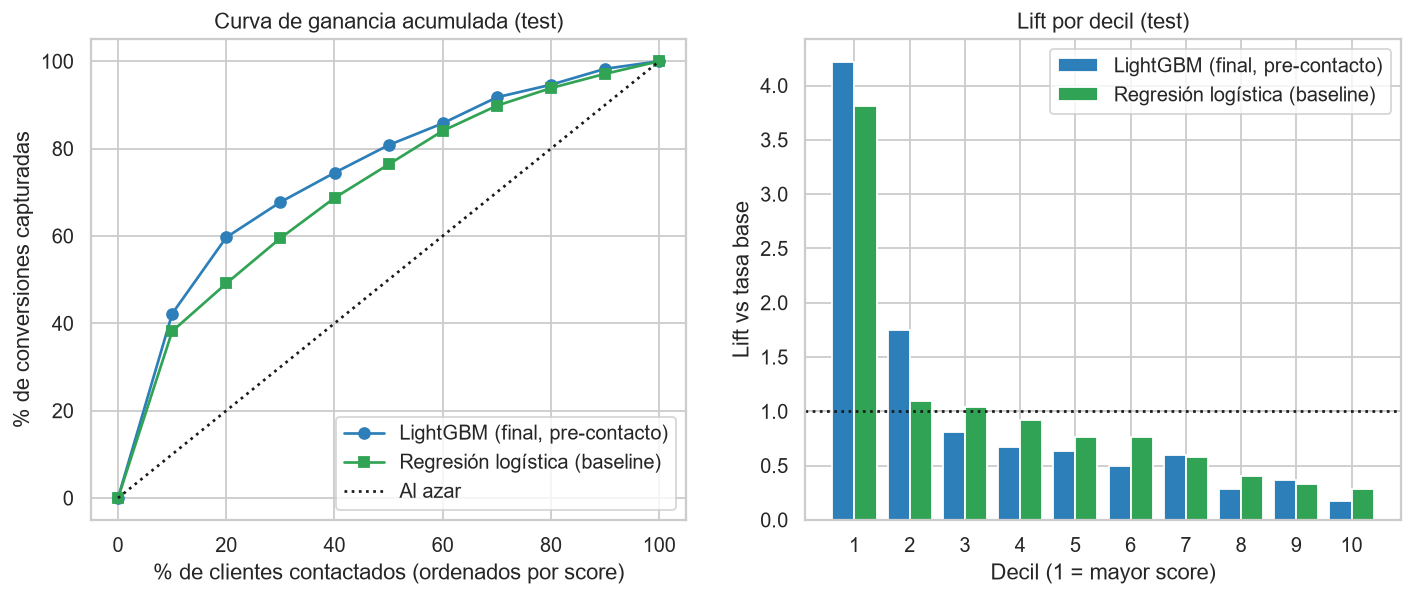

In [5]:
table('test_deciles.csv')
show('test_gain_lift.png')

El primer decil concentra 220 de las 521 conversiones (42 %, tasa 48,6 %, lift 4,2). Con el 20 % mejor rankeado se captura el 60 % de las conversiones y con el 30 %, el 68 %. Los deciles 8 a 10 casi no tienen conversiones (2–4 %).

## 4. Beneficio esperado y sensibilidad V/C

,strategy,contacted,contacted_pct,conversions,gain_pct,precision_pct,lift,profit,profit_vs_all
0,Top 10 % del ranking,453,10.00,220,42.23,48.57,4.21,3947.0,-1952.0
1,Top 20 % del ranking,905,20.00,311,59.69,34.36,2.98,5315.0,-584.0
2,Top 30 % del ranking,1357,30.00,353,67.75,26.01,2.26,5703.0,-196.0
3,Umbral operativo (0.050),2762,61.09,451,86.56,16.33,1.42,6258.0,359.0
4,Contactar a todos,4521,100.00,521,100.00,11.52,1.00,5899.0,0.0
5,No contactar a nadie,0,0.00,0,0.00,NaN,NaN,0.0,-5899.0


,vc_ratio,threshold_from_oof,contacted_pct,gain_pct,profit_model,profit_contact_all,profit_vs_all,profit_vs_all_pct
0,5.0,0.165,15.528,54.511,718.0,-1916.0,2634.0,137.474
1,10.0,0.110,23.336,62.380,2195.0,689.0,1506.0,218.578
2,20.0,0.050,61.093,86.564,6258.0,5899.0,359.0,6.086
3,50.0,0.023,97.346,99.616,21549.0,21529.0,20.0,0.093


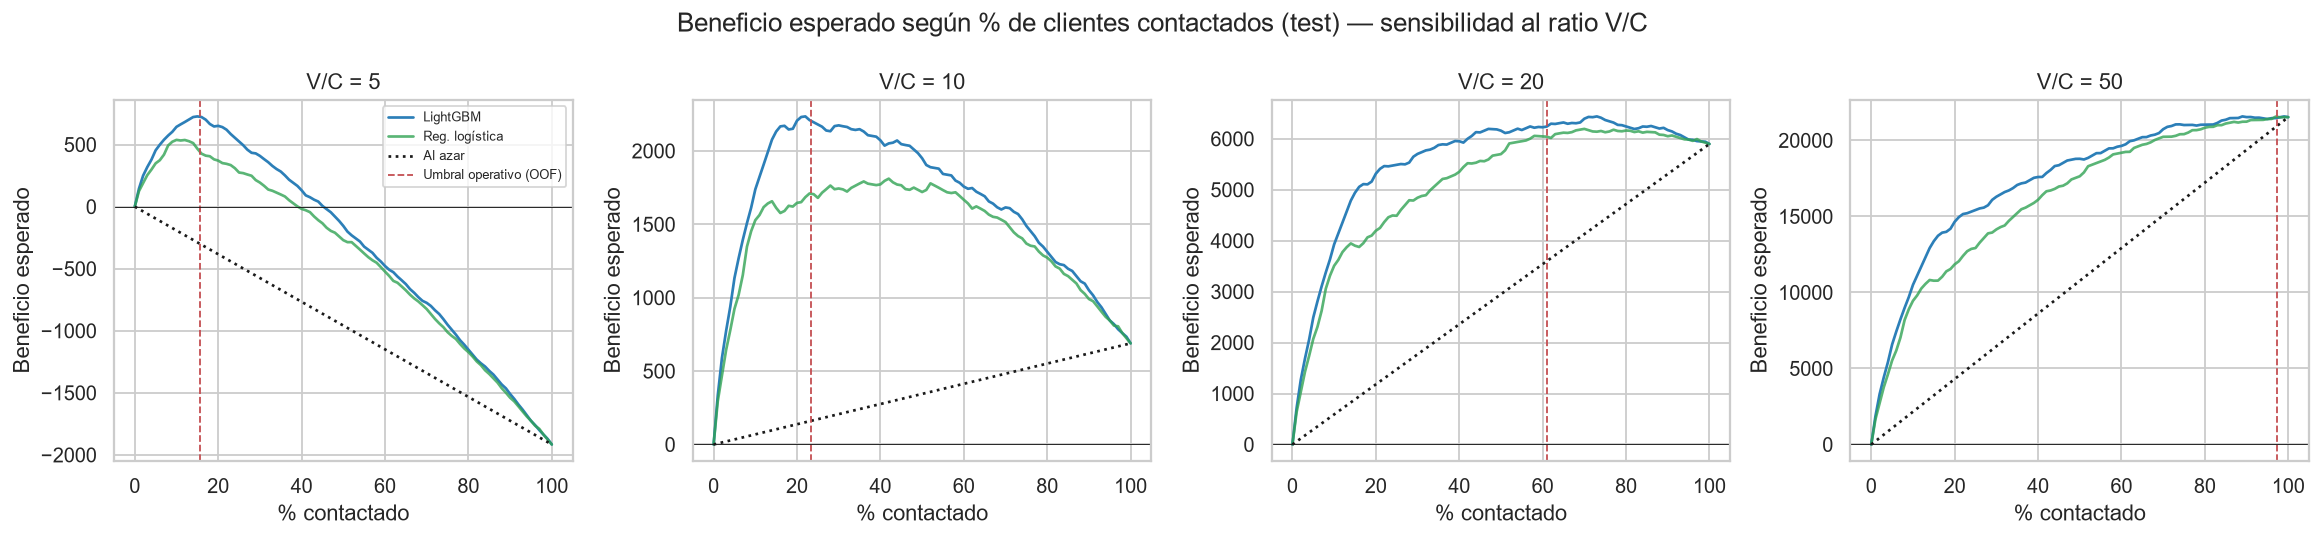

In [6]:
table('test_business_summary.csv')
table('test_sensitivity.csv')
show('test_profit_curves.png')

**Traducción a negocio.** Contactando al 20 % mejor rankeado se captura el 60 % de las conversiones, con una eficiencia 3 veces mayor que al azar. Con los supuestos V = 20 y C = 1, el máximo beneficio se logra con el umbral operativo (61 % contactado): 6.258 vs 5.899 de contactar a todos (+6 %).

El valor del modelo **depende del ratio V/C**: con V/C = 5 contactar a todos da pérdida (−1.916) y el modelo da ganancia (+718); con V/C = 10 el modelo triplica el beneficio (2.195 vs 689); con V/C = 50 conviene llamar a casi todos y el modelo apenas agrega valor. El modelo es más valioso cuanto más cara es la llamada respecto del valor de la conversión, o cuando hay un **presupuesto fijo** de llamadas (ahí importa el ranking: lift 4,2 en el top 10 %).

## 5. Calibración

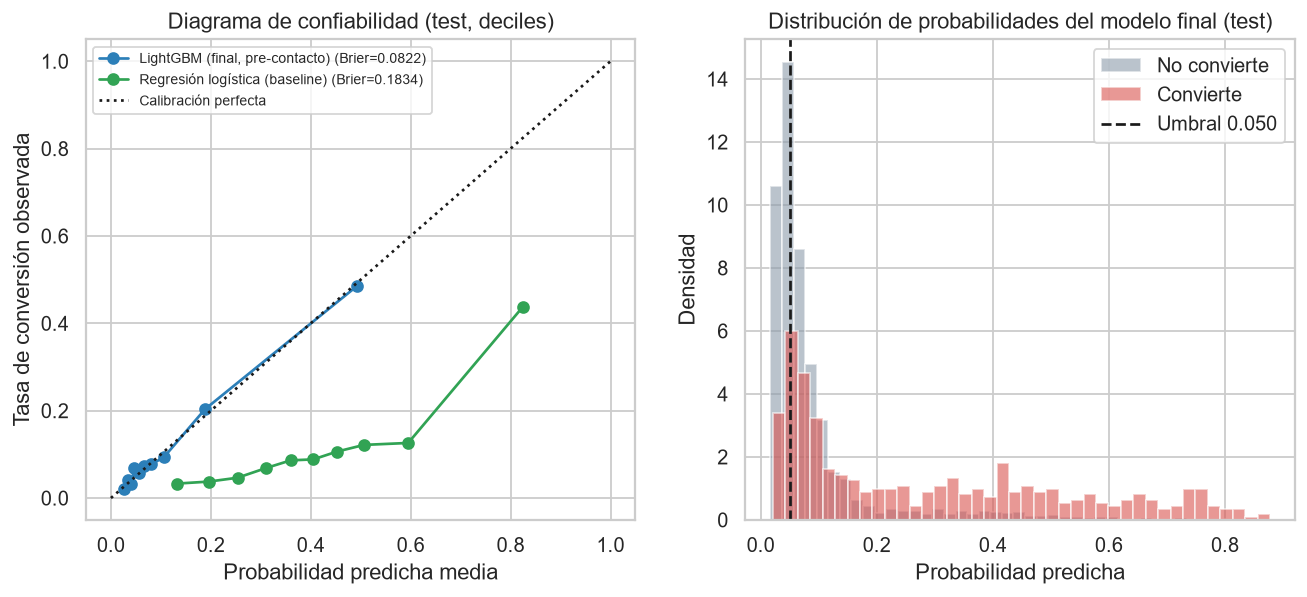

In [7]:
show('test_calibration.png')

LightGBM sin tratamiento de desbalance está bien calibrado (Brier 0,082; puntos cerca de la diagonal), lo que valida usar sus probabilidades para estimar conversiones y beneficio. La regresión logística con `class_weight='balanced'` sobreestima sistemáticamente (Brier 0,183): por eso su umbral óptimo es 0,275 y no 0,05.

## 6. Leakage: pre-contacto vs con `duration`

In [8]:
table('test_leakage.csv')

,model,label,roc_auc,pr_auc,lift@10,lift@20,gain@20,brier
0,final,"LightGBM (final, pre-contacto)",0.7836,0.4354,4.2143,2.9820,0.5969,0.0822
1,with_duration,LightGBM + duration (leakage),0.9326,0.6072,5.4785,4.1614,0.8330,0.0622


,model,label,roc_auc,pr_auc,lift@10,lift@20,gain@20,brier
0,final,"LightGBM (final, pre-contacto)",0.7836,0.4354,4.2143,2.9820,0.5969,0.0822
1,with_duration,LightGBM + duration (leakage),0.9326,0.6072,5.4785,4.1614,0.8330,0.0622


Con `duration`: ROC-AUC 0,933 y PR-AUC 0,607 (vs 0,784 y 0,435). La mejora es **ilusoria**: para conocer la duración hay que haber hecho la llamada, justo lo que el modelo debe decidir. Además la causalidad está invertida: la llamada es larga porque el cliente está interesado. Ese modelo mostraría métricas excelentes en validación y no podría usarse en producción.

## 7. Explicabilidad global (SHAP)

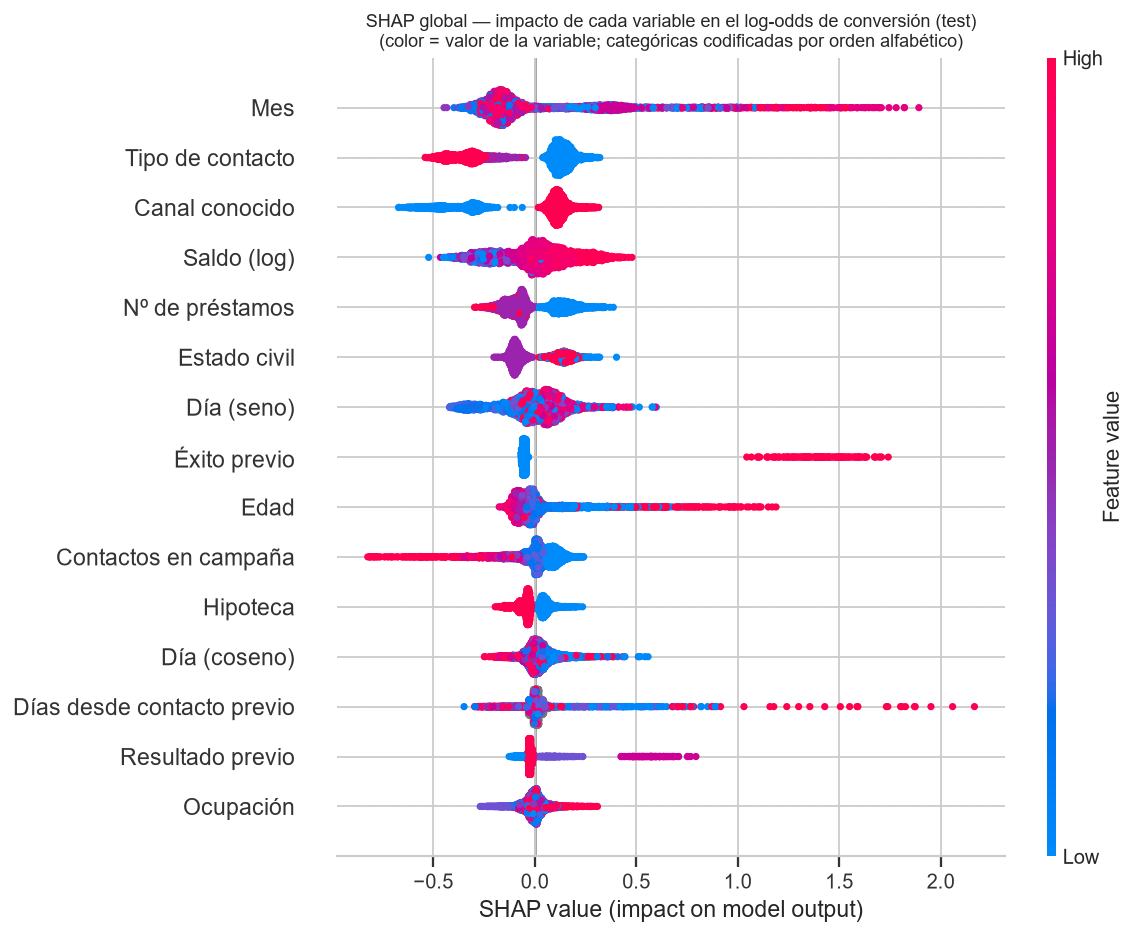

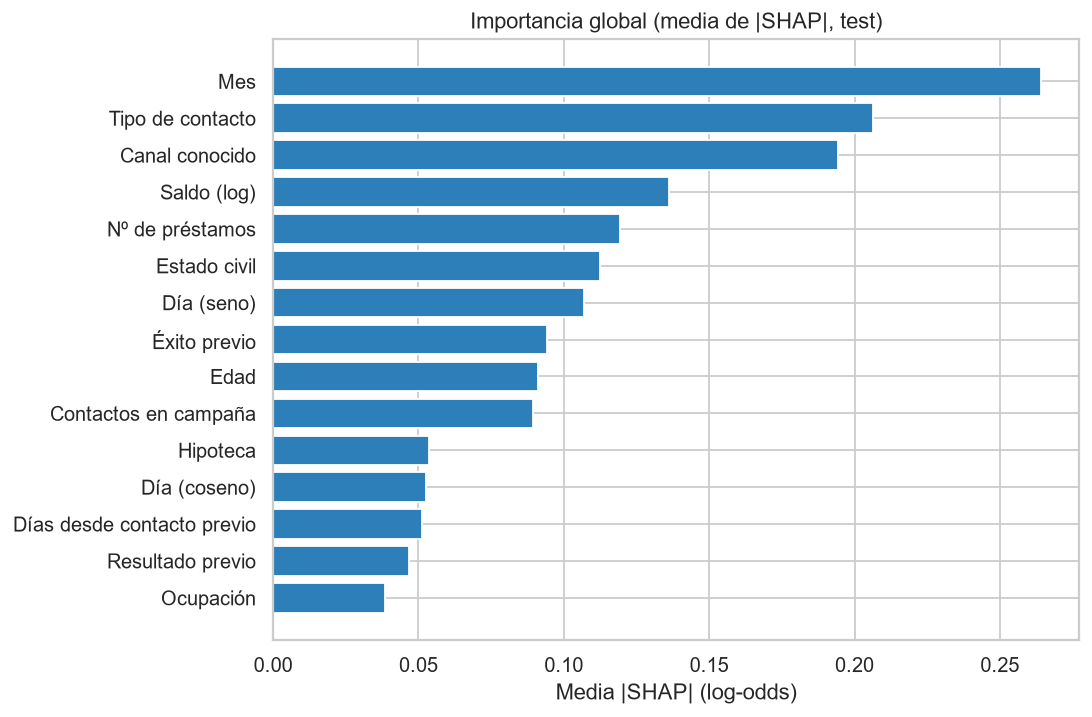

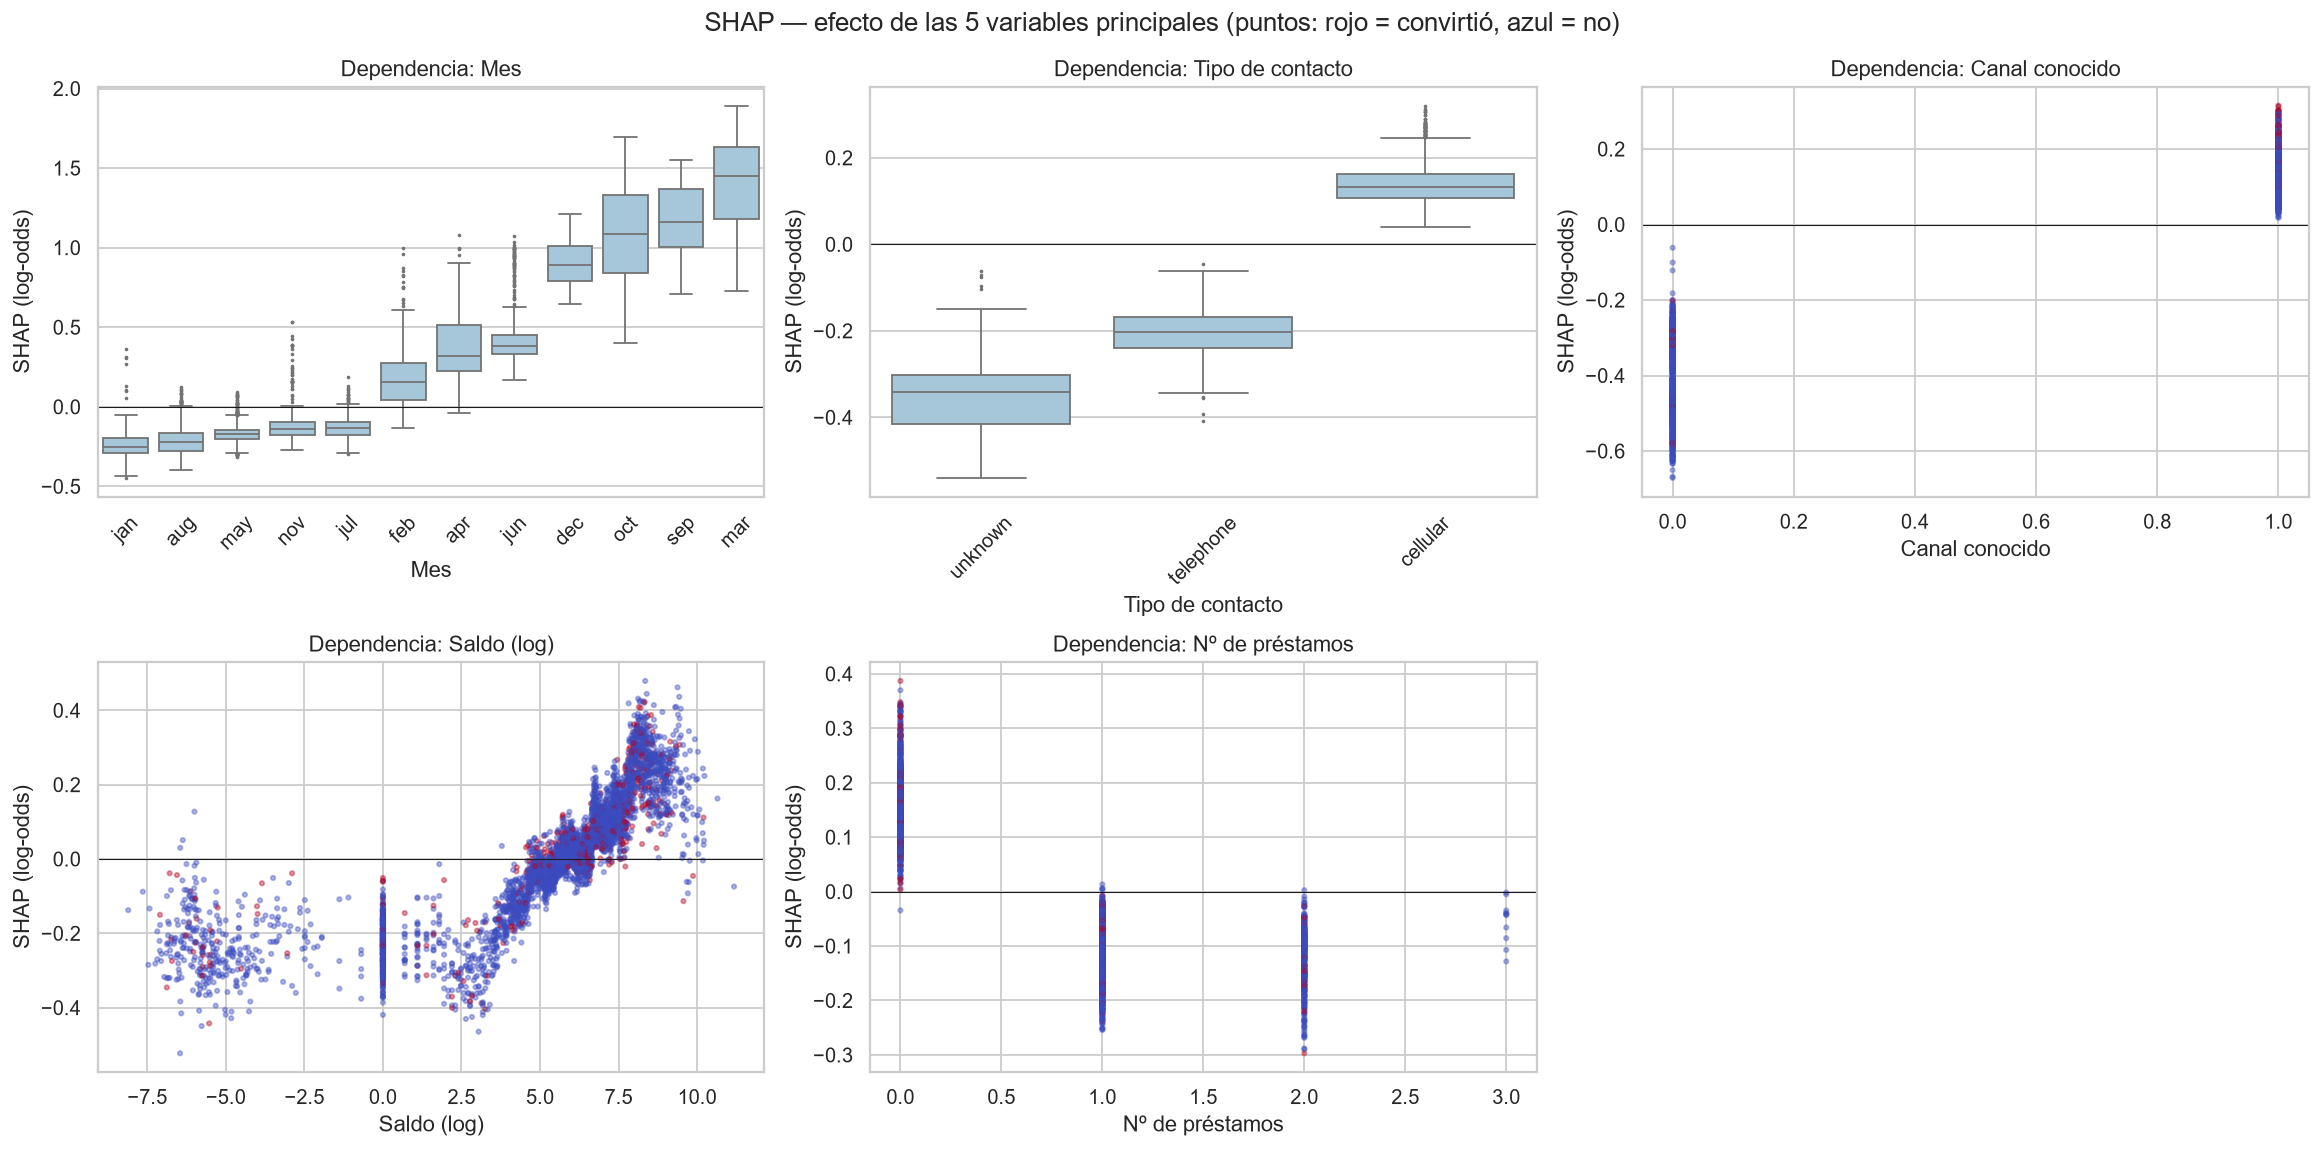

,feature,label,mean_abs_shap,share_pct
0,month,Mes,0.26407,14.89619
1,contact,Tipo de contacto,0.20624,11.63367
2,contact_known,Canal conocido,0.19440,10.96597
3,balance_log,Saldo (log),0.13620,7.68279
4,n_credit_products,Nº de préstamos,0.11944,6.73764
5,marital,Estado civil,0.11246,6.34396
6,day_sin,Día (seno),0.10701,6.03645
7,prev_campaign_success,Éxito previo,0.09437,5.32355
8,age,Edad,0.09118,5.14348
9,campaign_w,Contactos en campaña,0.08933,5.03928


,feature,label,mean_abs_shap,share_pct
0,month,Mes,0.26407,14.89619
1,contact,Tipo de contacto,0.20624,11.63367
2,contact_known,Canal conocido,0.19440,10.96597
3,balance_log,Saldo (log),0.13620,7.68279
4,n_credit_products,Nº de préstamos,0.11944,6.73764
5,marital,Estado civil,0.11246,6.34396
6,day_sin,Día (seno),0.10701,6.03645
7,prev_campaign_success,Éxito previo,0.09437,5.32355
8,age,Edad,0.09118,5.14348
9,campaign_w,Contactos en campaña,0.08933,5.03928


In [9]:
show('shap_summary.png')
show('shap_importance.png')
show('shap_dependence.png')
table('shap_importance.csv')

- **Mes** es la variable más influyente (15 % de la importancia): marzo, septiembre, octubre y diciembre suben fuerte la probabilidad; mayo, enero y agosto la bajan. Como se vio en el EDA, refleja la operación y el período más que al cliente: es el principal riesgo para campañas futuras.
- **Tipo de contacto / canal conocido** (juntas ≈ 23 %): `unknown` baja la probabilidad. Son dos codificaciones de la misma información y se reparten la importancia.
- **Saldo**: efecto creciente a partir de saldos positivos; negativos y ceros restan.
- **Nº de préstamos**: sin préstamos suma; con 1 o más resta.
- **Éxito previo**: afecta a pocos clientes pero con efecto enorme (+1,0 a +1,7 log-odds).
- **Contactos en la campaña**: muchos contactos restan (insistir no funciona). La **edad** alta suma.

## 8. Explicaciones locales (verdadero positivo, falso positivo, falso negativo)

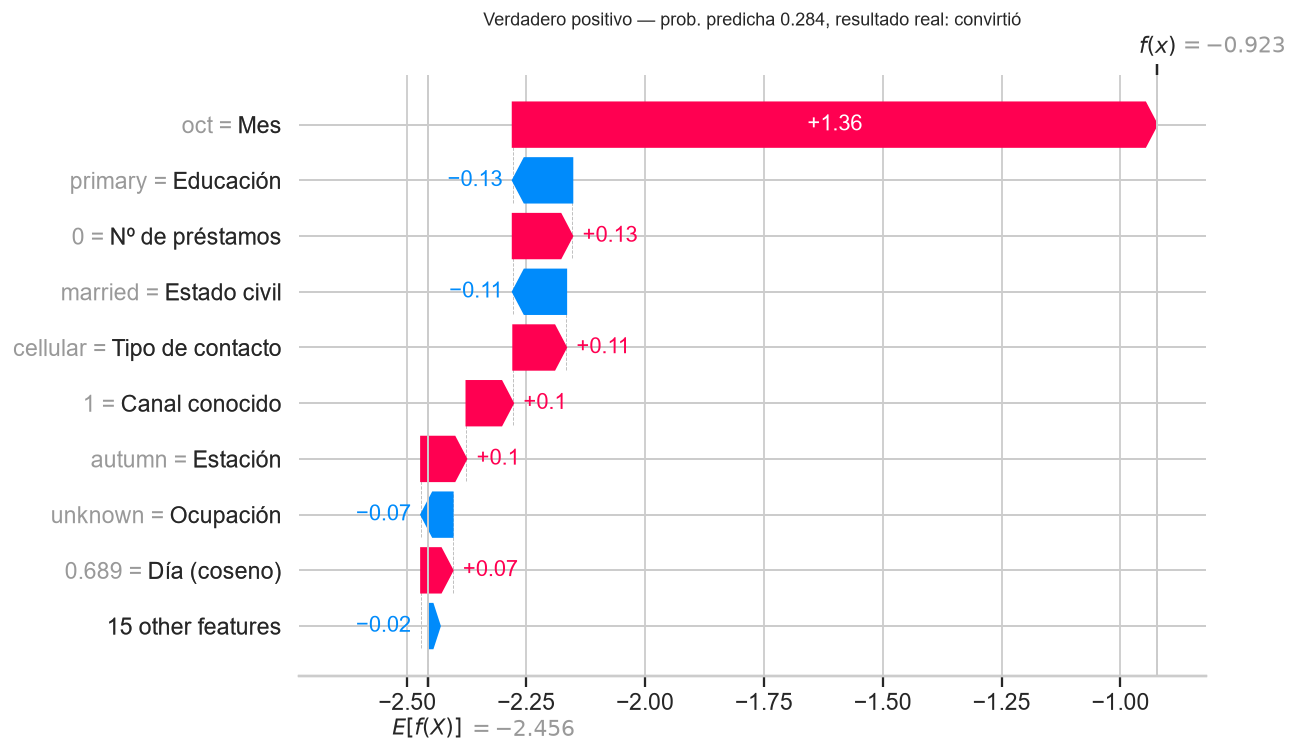

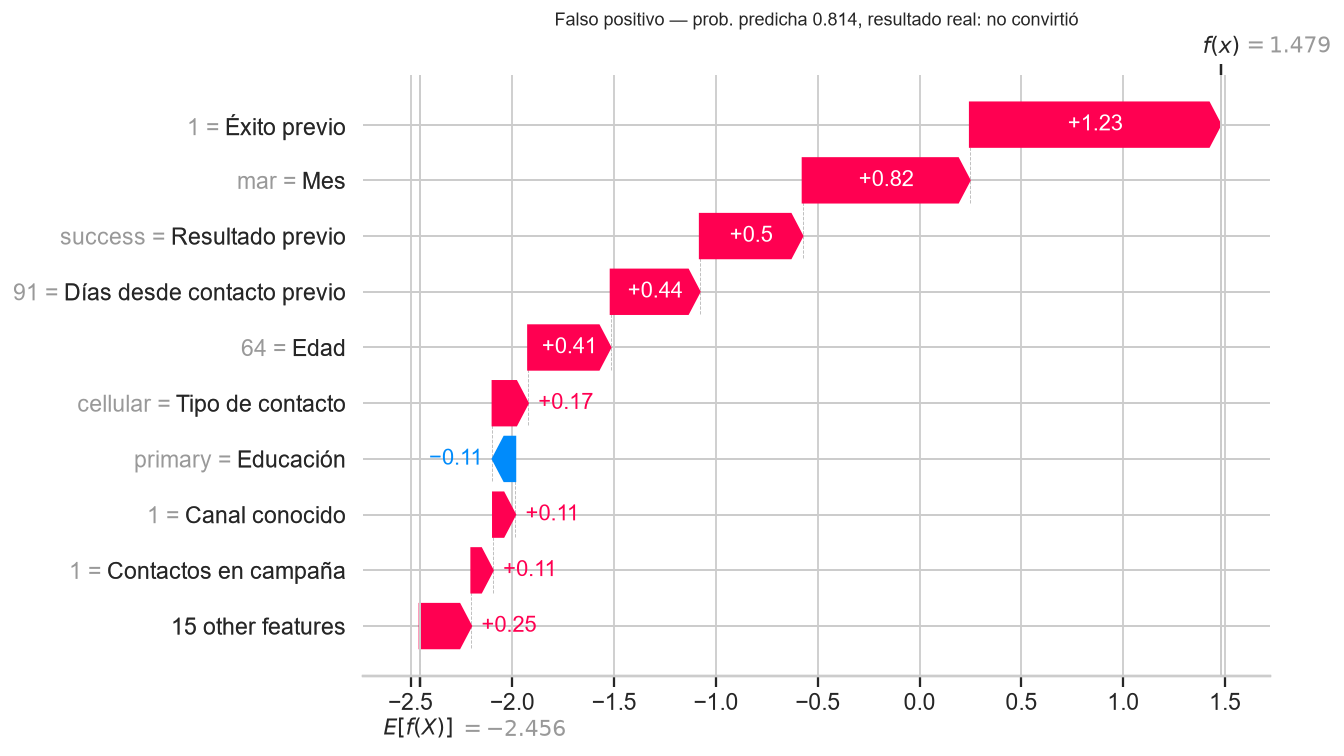

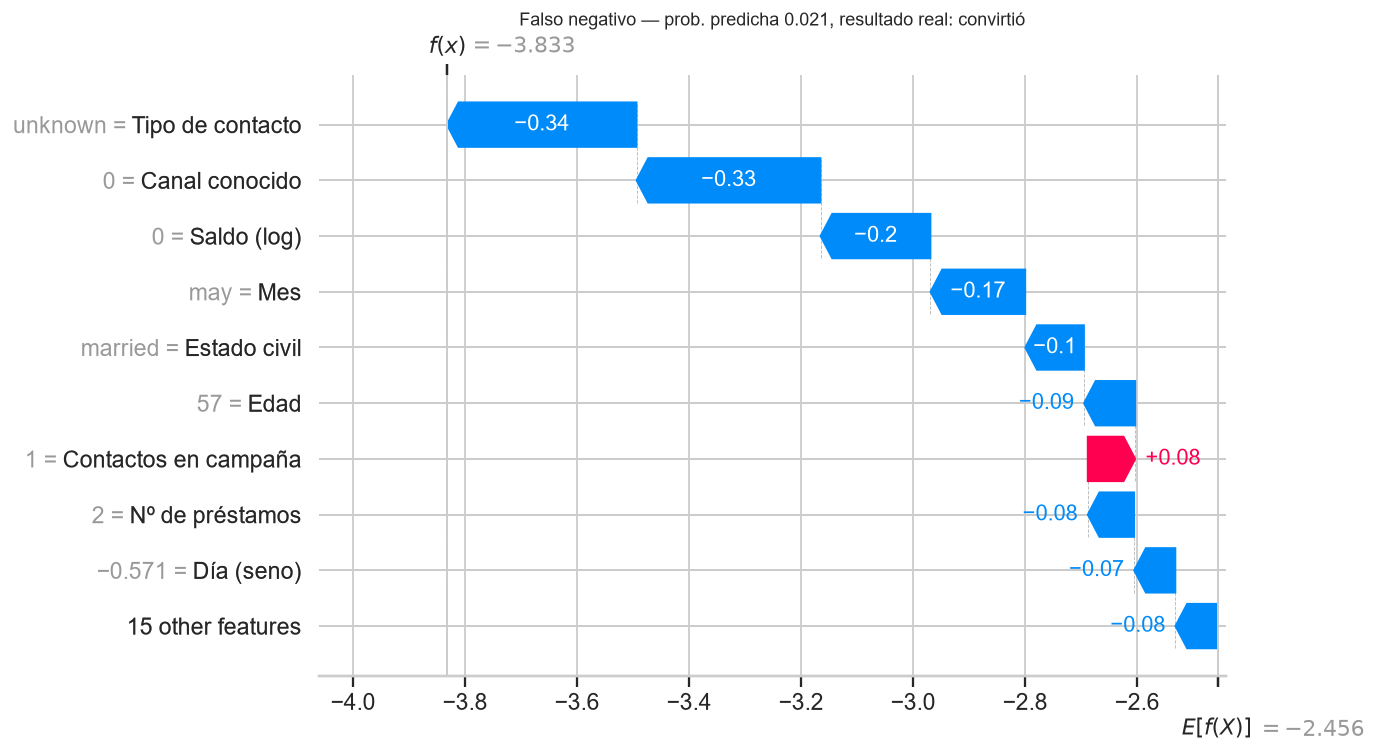

# Explicaciones locales (SHAP)

Valor base (log-odds medio del modelo): -2.456 → probabilidad 0.079. Umbral operativo: 0.050.

## Verdadero positivo (fila 2477 del test)

- Cliente: 53 años, ocupación `unknown`, estado civil `married`, educación `primary`, saldo 732, hipoteca `no`, préstamo `no`, contacto `cellular`, mes `oct`, contactos en campaña 2, resultado previo `unknown`.
- Probabilidad predicha: **0.284** (umbral 0.050) → llamar. Resultado real: **convirtió**.
- Factores que más **aumentan** la probabilidad: Mes = oct (+1.36), Nº de préstamos = 0 (+0.13), Tipo de contacto = cellular (+0.11).
- Factores que más la **reducen**: Educación = primary (-0.13), Estado civil = married (-0.11), Ocupación = unknown (-0.07).

## Falso positivo (fila 657 del test)

- Cliente: 64 años, ocupación `retired`, estado civil `married`, educación `primary`, saldo 43, hipoteca `no`, préstamo `no`, contacto `cellular`, mes `mar`, contactos en campaña 1, resultado previo `success`.
- Probabilidad pre

In [10]:
for c in ['tp', 'fp', 'fn']:
    show(f'shap_local_{c}.png')
print((cfg.TABLES_DIR / 'shap_local_cases.md').read_text(encoding='utf-8'))

- **Verdadero positivo**: cliente contactado por celular en octubre y sin préstamos; el mes explica casi toda la suba (probabilidad 0,28, muy por encima del umbral).
- **Falso positivo** (el de mayor probabilidad): jubilado con **éxito en la campaña anterior**, contactado en marzo. Todo indicaba conversión (0,81) y no convirtió: un error razonable, cualquier analista lo habría llamado.
- **Falso negativo** (el de menor probabilidad): contacto `unknown` en mayo, saldo cero, hipoteca y préstamo personal. Es el perfil de menor conversión del dataset; su conversión no era predecible con la información previa a la llamada.

## 9. Contraste: coeficientes de la regresión logística

,feature,coef,odds_ratio,abs_coef
0,month_mar,1.0241,2.7847,1.0241
1,month_nov,-0.9813,0.3748,0.9813
2,month_dec,0.9444,2.5712,0.9444
3,age_group_65+,0.9399,2.5598,0.9399
4,month_jan,-0.8445,0.4298,0.8445
...,...,...,...,...
62,job_services,-0.0163,0.9838,0.0163
63,job_technician,0.0149,1.0150,0.0149
64,job_blue-collar,-0.0086,0.9914,0.0086
65,day_cos,-0.0004,0.9996,0.0004


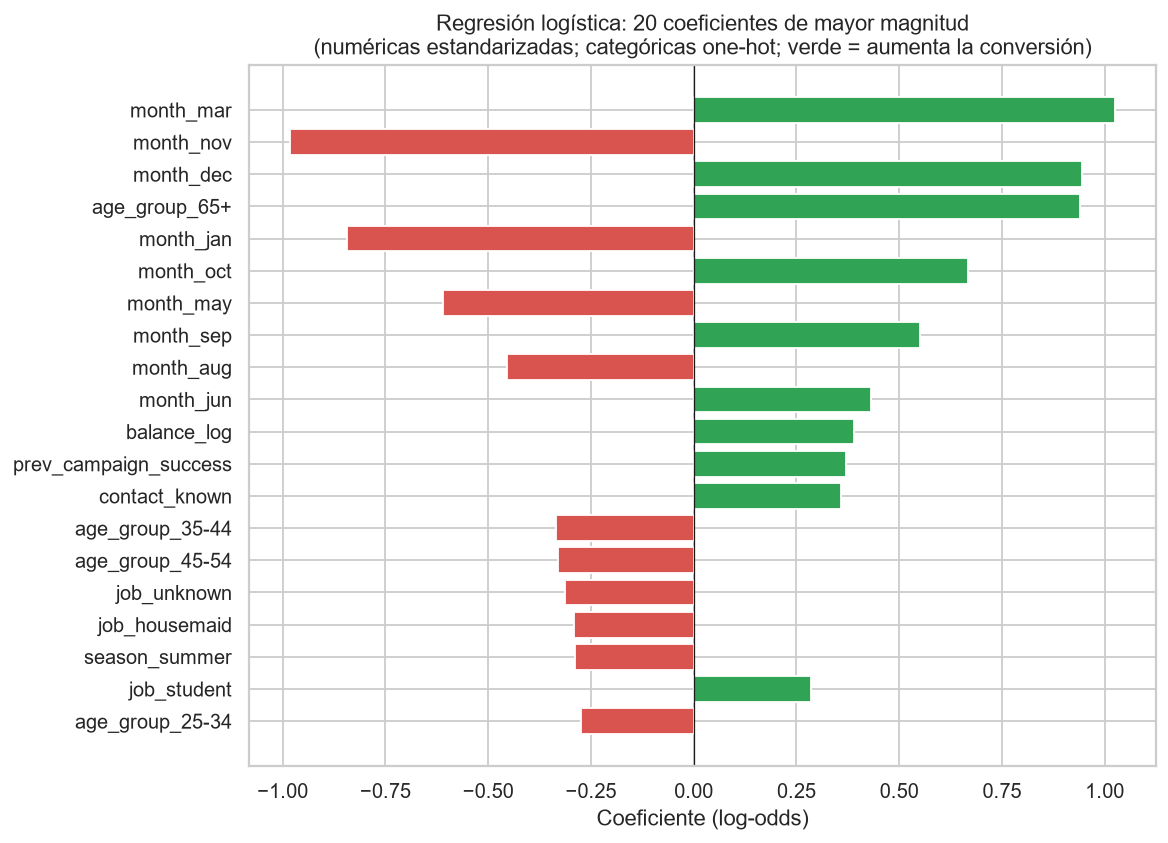

In [11]:
table('logreg_coefficients.csv').head(20)
show('logreg_coefficients.png')

La regresión logística coincide en lo esencial con SHAP: los coeficientes más grandes son de **mes** (marzo OR 2,8, diciembre 2,6, octubre 1,9; noviembre 0,37, enero 0,43, mayo 0,54), el grupo de 65+ (OR 2,6) y el saldo. Que dos familias de modelos distintas lleguen a las mismas variables da confianza en que las relaciones son reales.

## 10. Reglas de negocio: árbol de profundidad 3

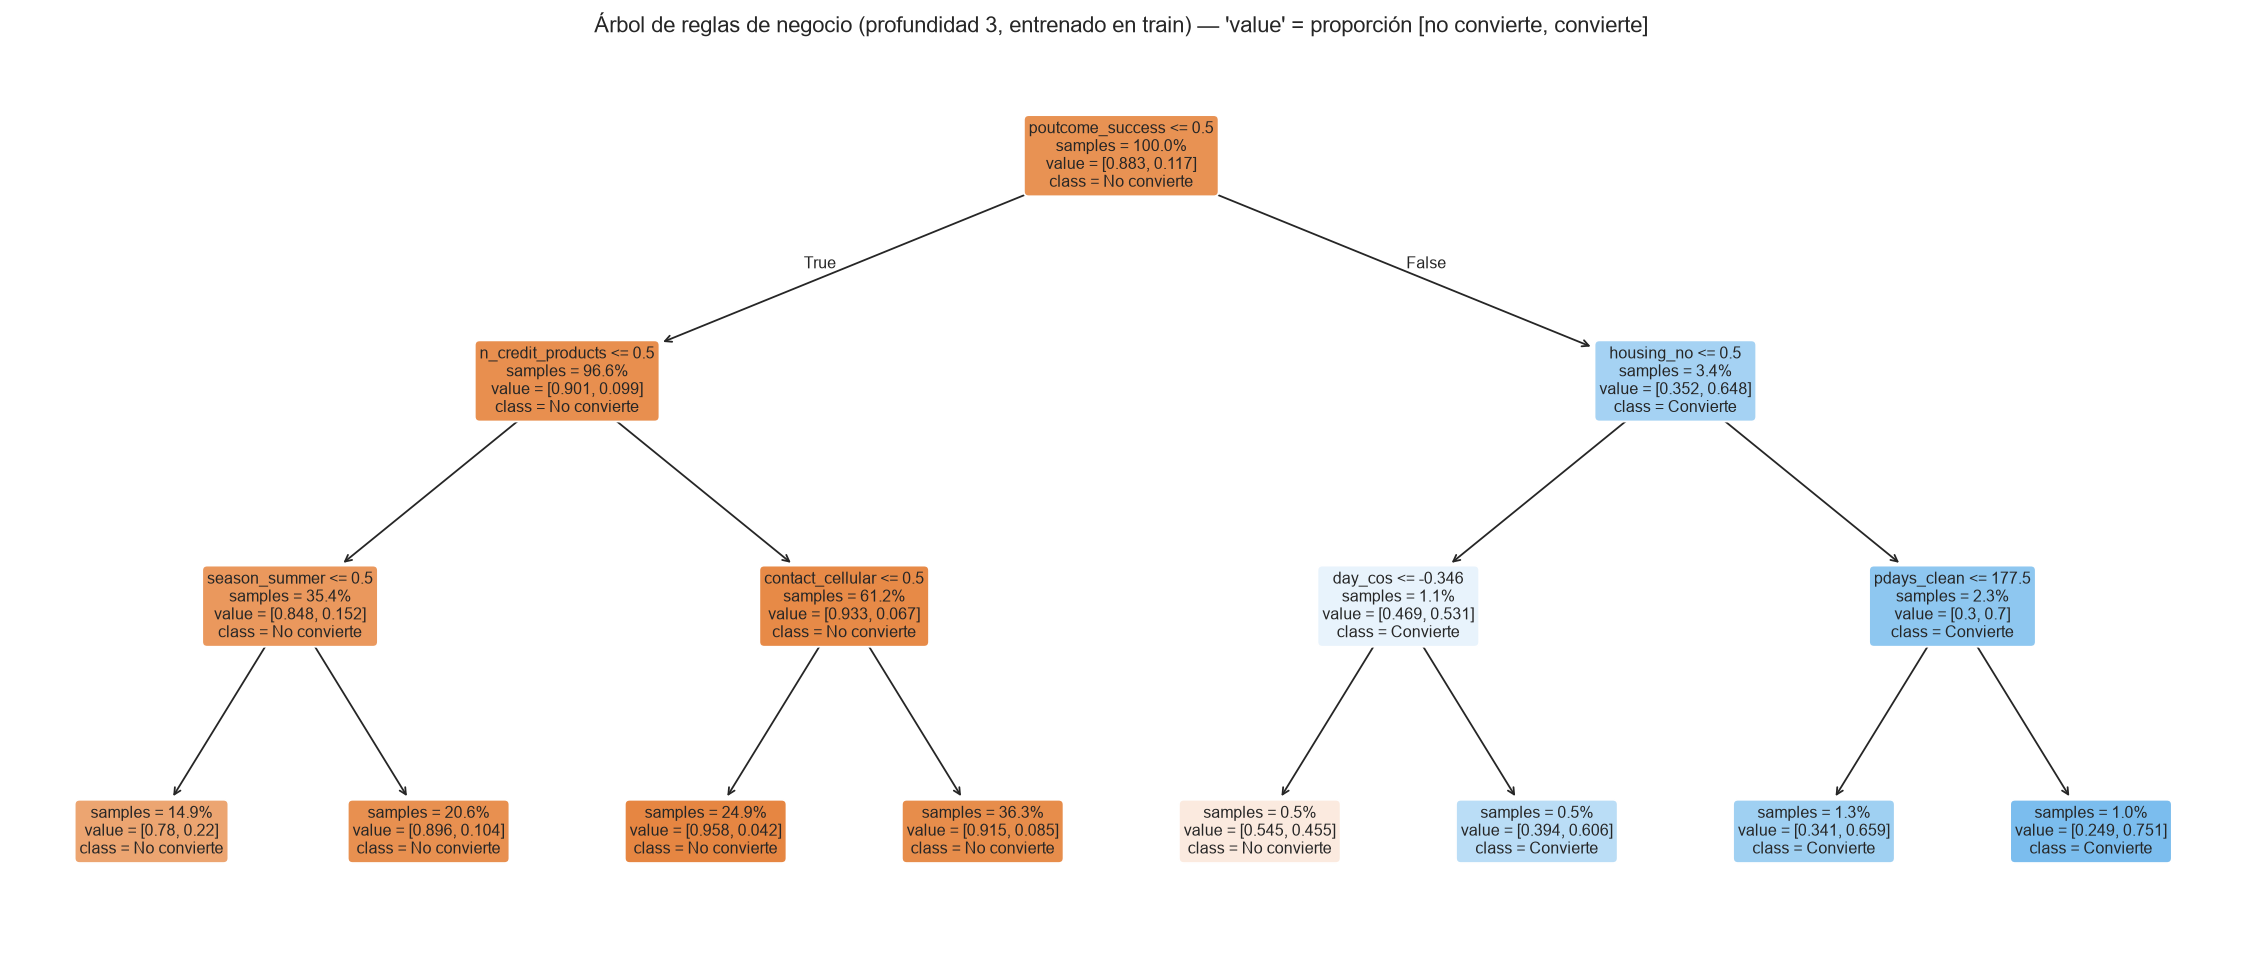

|--- poutcome_success <= 0.50
|   |--- n_credit_products <= 0.50
|   |   |--- season_summer <= 0.50
|   |   |   |--- weights: [4718.00, 1330.00] class: 0
|   |   |--- season_summer >  0.50
|   |   |   |--- weights: [7501.00, 868.00] class: 0
|   |--- n_credit_products >  0.50
|   |   |--- contact_cellular <= 0.50
|   |   |   |--- weights: [9709.00, 423.00] class: 0
|   |   |--- contact_cellular >  0.50
|   |   |   |--- weights: [13507.00, 1252.00] class: 0
|--- poutcome_success >  0.50
|   |--- housing_no <= 0.50
|   |   |--- day_cos <= -0.35
|   |   |   |--- weights: [116.00, 97.00] class: 0
|   |   |--- day_cos >  -0.35
|   |   |   |--- weights: [86.00, 132.00] class: 1
|   |--- housing_no >  0.50
|   |   |--- pdays_clean <= 177.50
|   |   |   |--- weights: [179.00, 346.00] class: 1
|   |   |--- pdays_clean >  177.50
|   |   |   |--- weights: [106.00, 320.00] class: 1



,rule,n_train,share_pct,conversion_rate,lift
0,poutcome = success Y housing = no Y pdays_clea...,426,1.0469,0.7512,6.4105
1,poutcome = success Y housing = no Y pdays_clea...,525,1.2902,0.6590,5.6243
2,poutcome = success Y housing = yes Y day_cos >...,218,0.5358,0.6055,5.1674
3,poutcome = success Y housing = yes Y day_cos <...,213,0.5235,0.4554,3.8864
4,poutcome != success Y n_credit_products <= 0.5...,6048,14.8636,0.2199,1.8767
5,poutcome != success Y n_credit_products <= 0.5...,8369,20.5677,0.1037,0.8851
6,poutcome != success Y n_credit_products > 0.50...,14759,36.2718,0.0848,0.7239
7,poutcome != success Y n_credit_products > 0.50...,10132,24.9005,0.0417,0.3563


,rule,n_train,share_pct,conversion_rate,lift
0,poutcome = success Y housing = no Y pdays_clea...,426,1.0469,0.7512,6.4105
1,poutcome = success Y housing = no Y pdays_clea...,525,1.2902,0.6590,5.6243
2,poutcome = success Y housing = yes Y day_cos >...,218,0.5358,0.6055,5.1674
3,poutcome = success Y housing = yes Y day_cos <...,213,0.5235,0.4554,3.8864
4,poutcome != success Y n_credit_products <= 0.5...,6048,14.8636,0.2199,1.8767
5,poutcome != success Y n_credit_products <= 0.5...,8369,20.5677,0.1037,0.8851
6,poutcome != success Y n_credit_products > 0.50...,14759,36.2718,0.0848,0.7239
7,poutcome != success Y n_credit_products > 0.50...,10132,24.9005,0.0417,0.3563


In [12]:
show('rules_tree_depth3.png')
print((cfg.TABLES_DIR / 'rules_tree_depth3.txt').read_text(encoding='utf-8'))
table('rules_tree_leaves.csv')

Reglas simples para el equipo comercial (tasas medidas en train):

1. **Éxito en la campaña anterior y sin hipoteca** → 66–75 % de conversión (lift 5,6–6,4). Llamar siempre.
2. Éxito anterior con hipoteca → 46–61 %.
3. Sin éxito previo, **sin préstamos** y fuera del verano → 22 % (lift 1,9).
4. Sin éxito previo, **con préstamos** y contacto no celular → 4 % (lift 0,36). Última prioridad.

El árbol de profundidad 3 obtiene ROC-AUC 0,675 en test: sirve para comunicar, no para reemplazar al modelo.

## 11. Análisis de errores

In [13]:
table('error_profiles.csv')
table('error_categorical_profiles.csv').head(40)

,grupo,n,age,balance,campaign,pdays,previous,day,score,pct_previously_contacted
0,TP,451,42.492,1728.532,2.064,74.860,1.224,15.537,0.325,39.2
1,FN,70,42.486,563.157,3.571,28.557,0.229,16.443,0.039,10.0
2,FP,2311,40.326,1760.819,2.397,43.540,0.595,14.942,0.131,19.6
3,TN,1689,41.917,913.911,3.499,25.697,0.302,17.326,0.036,10.6


,variable,category,pct_FN,pct_FP,pct_TN,pct_TP
0,job,admin.,11.4,11.5,9.1,11.1
1,job,blue-collar,24.3,17.0,28.6,11.5
2,job,entrepreneur,5.7,3.5,4.2,2.4
3,job,housemaid,2.9,1.8,3.3,2.7
4,job,management,15.7,23.2,17.9,26.6
5,job,retired,8.6,5.5,2.9,10.6
6,job,self-employed,4.3,4.1,4.1,3.8
7,job,services,7.1,9.1,10.0,7.3
8,job,student,0.0,2.3,0.7,4.2
9,job,technician,20.0,17.6,16.5,15.3


,variable,category,pct_FN,pct_FP,pct_TN,pct_TP
0,job,admin.,11.4,11.5,9.1,11.1
1,job,blue-collar,24.3,17.0,28.6,11.5
2,job,entrepreneur,5.7,3.5,4.2,2.4
3,job,housemaid,2.9,1.8,3.3,2.7
4,job,management,15.7,23.2,17.9,26.6
5,job,retired,8.6,5.5,2.9,10.6
6,job,self-employed,4.3,4.1,4.1,3.8
7,job,services,7.1,9.1,10.0,7.3
8,job,student,0.0,2.3,0.7,4.2
9,job,technician,20.0,17.6,16.5,15.3


- **Falsos negativos (70)**: se parecen a los verdaderos negativos y no a los verdaderos positivos: 61 % con contacto `unknown` (vs 4 % en TP), 49 % en mayo (vs 13 %), saldo medio 563 (vs 1.729), más contactos en la campaña (3,6 vs 2,1) y solo 10 % contactados antes (vs 39 %). Son conversiones inesperadas dentro de campañas masivas; no hay señal previa que las distinga.
- **Falsos positivos (2.311)**: se parecen a los TP (canal celular 84 %, la mitad sin hipoteca). Con un umbral de 0,05 son la contracara buscada de un recall alto.

## 12. Métricas por segmento

,segment_var,segment,n,conversions,conversion_rate,roc_auc,pr_auc,recall_at_thr,precision_at_thr,mean_score,reliable
0,age_group,65+,89,32,0.3596,0.6179,0.5325,1.0000,0.3596,0.4014,True
1,age_group,<25,67,13,0.1940,0.6795,0.3463,0.9231,0.2222,0.2077,False
2,age_group,25-34,1405,165,0.1174,0.7604,0.4109,0.8909,0.1498,0.1196,True
3,age_group,45-54,1008,114,0.1131,0.7806,0.4504,0.7895,0.1734,0.0913,True
4,age_group,55-64,496,60,0.1210,0.7879,0.4610,0.8500,0.1729,0.1232,True
5,age_group,35-44,1456,137,0.0941,0.7938,0.4479,0.8686,0.1444,0.0976,True
6,contact,unknown,1324,61,0.0461,0.6459,0.0973,0.2951,0.0756,0.0415,True
7,contact,cellular,2896,416,0.1436,0.7752,0.4628,0.9399,0.1683,0.1444,True
8,contact,telephone,301,44,0.1462,0.8433,0.5831,0.9545,0.2090,0.1326,True
9,job,entrepreneur,168,15,0.0893,0.6580,0.3034,0.7333,0.1183,0.0698,False


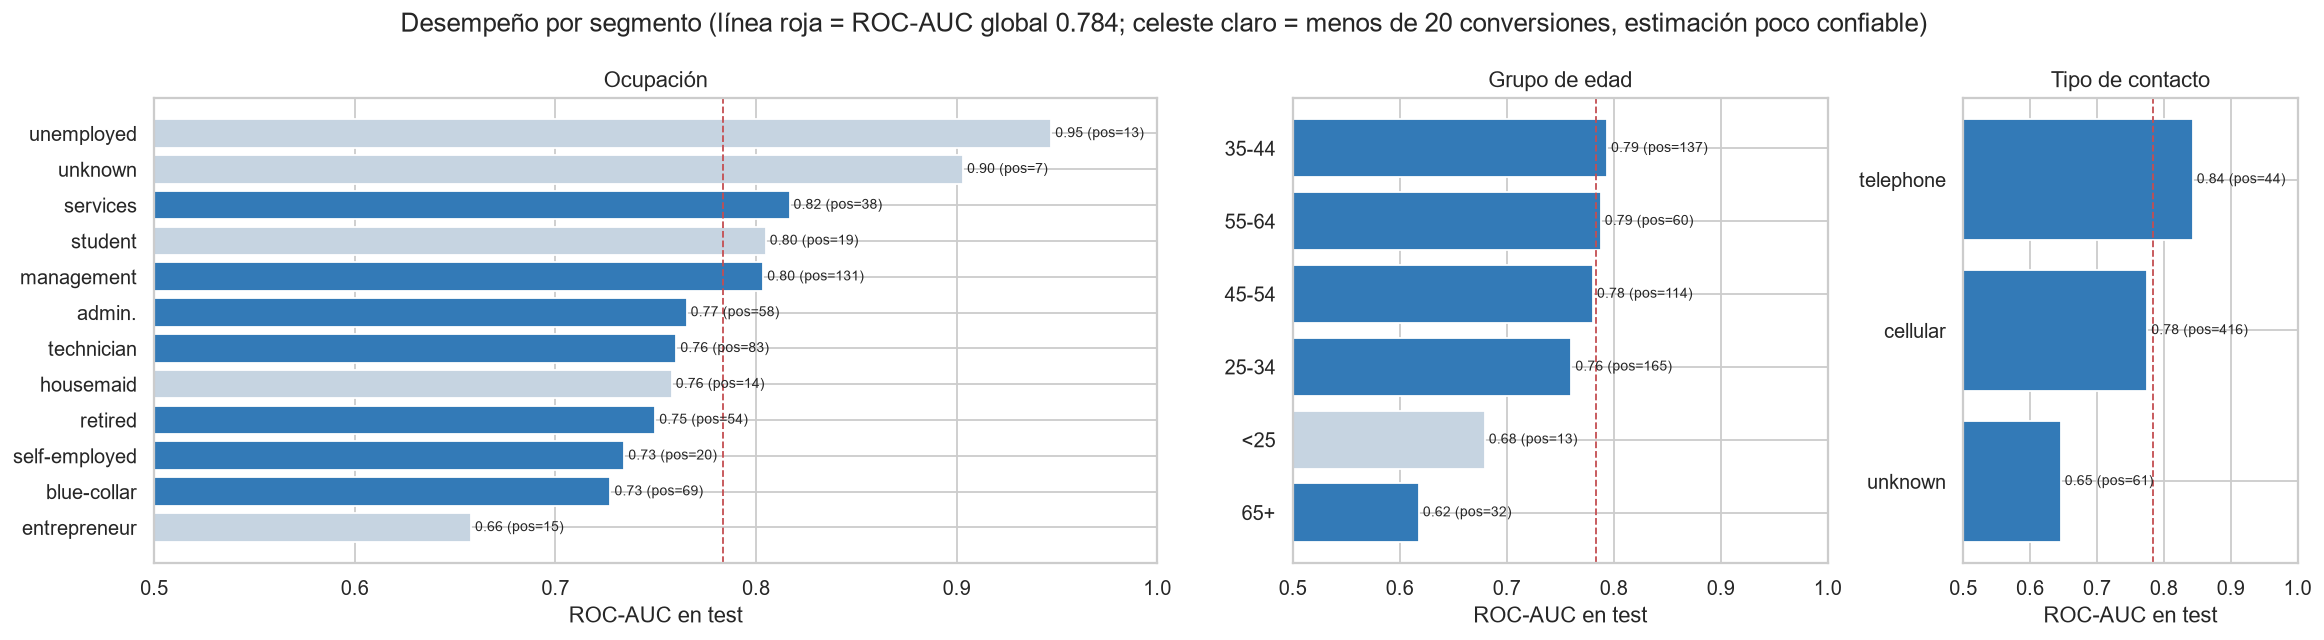

In [14]:
table('segment_metrics.csv')
show('segment_metrics.png')

- El segmento más débil es **contact = unknown** (ROC-AUC 0,65; 1.324 clientes, 4,6 % de conversión).
- **Mayores de 65** (0,62) y **menores de 25** (0,68, poco confiable): convierten mucho en promedio (36 % y 19 %) y el modelo los pone arriba a todos, pero discrimina poco dentro del grupo.
- Por ocupación, blue-collar y self-employed (0,73) son los más difíciles con muestra suficiente; management y services, los mejores (> 0,80).
- Para esos segmentos convendría sumar información (por ejemplo, historial transaccional).

## 13. Razonabilidad frente a la literatura

In [15]:
table('reasonableness.csv')

,check,value,reference,ok
0,"ROC-AUC sin duration vs referencia 0,75–0,80",0.7836,"0,75–0,80 (rango de referencia del enunciado p...",True
1,ROC-AUC con duration (leakage) en rango típico...,0.9326,"> 0,90 esperado: duration por sí sola tiene RO...",True
2,PR-AUC muy por encima del azar (prevalencia),0.4354,piso = prevalencia en test (0.115),True
3,Modelo final supera a la regresión logística,0.4354,PR-AUC logística = 0.3494,True
4,PR-AUC en test dentro de ±2 desvíos de la CV,0.4354,CV = 0.4660 ± 0.0201,True


,check,value,reference,ok
0,"ROC-AUC sin duration vs referencia 0,75–0,80",0.7836,"0,75–0,80 (rango de referencia del enunciado p...",True
1,ROC-AUC con duration (leakage) en rango típico...,0.9326,"> 0,90 esperado: duration por sí sola tiene RO...",True
2,PR-AUC muy por encima del azar (prevalencia),0.4354,piso = prevalencia en test (0.115),True
3,Modelo final supera a la regresión logística,0.4354,PR-AUC logística = 0.3494,True
4,PR-AUC en test dentro de ±2 desvíos de la CV,0.4354,CV = 0.4660 ± 0.0201,True


Los cinco chequeos de razonabilidad se cumplen. El ROC-AUC de 0,78 en test está dentro del rango de referencia 0,75–0,80 para este dataset sin `duration`; con `duration` supera 0,93. Si el modelo pre-contacto hubiera dado ROC-AUC > 0,90, habría sido una señal de fuga de información.